# NAME: ***David Onyema***
# STUDENT ID: ***100977305***
# TITLE: ***Does a lack of sleep affect stress level?***



## INTRODUCTION

##### In a generation experiencing increased stress alongside reduced sleep, many people are left wondering what the true cause of these rising stress levels is. We propose that the primary culprit may be a lack of sufficient sleep. In this project, data on over 300 individuals were collected from a Kaggle dataset (Sleep Health and Lifestyle Dataset by Laksika Tharmalingam). The dataset includes information on gender, age, sleep duration, sleep quality, sleep disorders, and, most importantly, stress levels. This data raised several key questions: Does a lack of the quality of sleep contribute to higher stress? Do age or even gender influence stress levels? And finally, are individuals with sleep disorders more likely to experience increased stress? In this project, we compare these factors to stress levels using metrics such as mean, maximum, minimum, counts, and graphical visualizations to draw a conclusion about what truly contributes to elevated stress levels in individuals.

## ANALYSES

##### In this section we first do **Data Collection**. Firstly we imported our data from kaggle (Sleep Health and Lifestyle Dataset by Laksika Tharmalingam) and import all our needed python libaries. The data we are going to use includes gender(male or female), age(in years), sleep duration(hours of sleep), sleep quality(quality of sleep on a scale of 1-10. 1 being bad and 10 being good), sleep disorders(Nan when the person has no disorders), and, most importantly, stress levels(level of stress form a scale of 1-10. 1 being good and 10 being bad)

##### Then **Data Cleaning** was performed in order to make analysis easier. Firstly, we edited the column names to be lowercase and unspaced to make data collection easier. Then we dropped all the uneeded data in the data frame. 

##### For the second part of **Data Cleaning**, after examining the dataset’s shape, we found that it contained 374 individuals. However, only 155 entries were present in the sleep_disorder column, meaning 219 values were missing. This was expected since not everyone has a sleep disorder. To simplify analysis, we encoded this column so that 1 indicates the individual has a disorder and 0 indicates they do not. Then we put the values of stress_level into 3 diff category (high, med, low) and was called "stress_level_code" . "high" stress was for values greater than equal to 7, "med" stress was for values greater than equal to 5 but less than 7 and values under 5 represented "low" stress levels. This categorogical system was also implemented on sleep duration and quality. The resulting data was placed under "quality_cat" for quality and "sleep_cat" for duration. However, "high" insinuated values greater than equal to 8, "med" was for values greater than equal to 6.5 but less than 8 and values below 6.5 represented "low". Finally we put floored the valued of age and put its values into categories like "20s", "30s" and so on. We stored this data under "age_cat".

##### Finally, in this section we did **Data Analysis**. We found the mean, max and min of significant data like age, stress level, sleep duration, quality of sleep and finally we compared the "stress_level_code" with "quality_cat", "sleep_cat", gender, age and sleep disorder aswell using the count of the idividuals under these categories using graphical represntations.

### *DATA COLLECTION* ###

In [13]:
# %pip install matplotlib
import sys
print(sys.executable)


/home/onyem/dataAnalysis/.venv/bin/python


In [14]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
path = "/home/onyem/.cache/kagglehub/datasets/uom190346a/sleep-health-and-lifestyle-dataset/versions/2/Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(path)

### *DATA CLEANING*

In [ ]:
print(f"Shape: {df.shape}")
print()
print("Count of Columns Values: ")
print(df.count())


In [16]:
def delspace(word):
    result =""
    for letter in word:
        if letter != " ":
            result+=letter
        else:
            result+="_"
    return result
df.columns = [l.lower() for l in df.columns]
df.columns = [delspace(l) for l in df.columns]
df.drop(["bmi_category", "blood_pressure", "heart_rate", "person_id","physical_activity_level", "daily_steps", "occupation"],axis =1 ,inplace = True)
df["sleep_disorder"] = [0 if l is None else 1 for l in df.sleep_disorder]
df["stress_level_code"] = ["low" if l < 5  else "med" if l>= 5 and l < 7 else "high" for l in df["stress_level"]] 
df["sleep_duration"] =df["sleep_duration"].round(0)
df["quality_cat"] = ["high" if l >=8 else "low" if l < 6.5 else "med" for l in df["quality_of_sleep"] ]
df["sleep_cat"] = ["high" if l >=8 else "low" if l < 6.5 else "med" for l in df["sleep_duration"] ]
df["age_cat"] = ["20s" if l >=20 and l <30 else "30s" if l >=30 and l < 40 else "40s" if l >= 40 and l < 50 else "50s" for l in df["age"]]

### *DATA ANALYSIS* ###

In [ ]:
pd.set_option("display.precision", 1) 
df_var = df.describe()
df_var = df_var.reindex(columns = ["age","sleep_duration", "quality_of_sleep", "stress_level"])
df_var["stress_level"].reindex(["min", "max", "mean"])


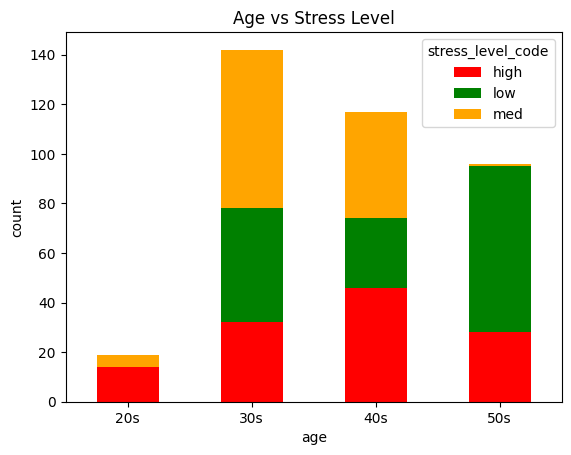

In [18]:
##comparing stress
##occupation and stress.
stress_occ = df.groupby("age_cat")["stress_level_code"].value_counts().unstack()
m = stress_occ.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("count")
plt.xlabel("age")
plt.title("Age vs Stress Level")
plt.xticks(rotation=0)
plt.show(m)

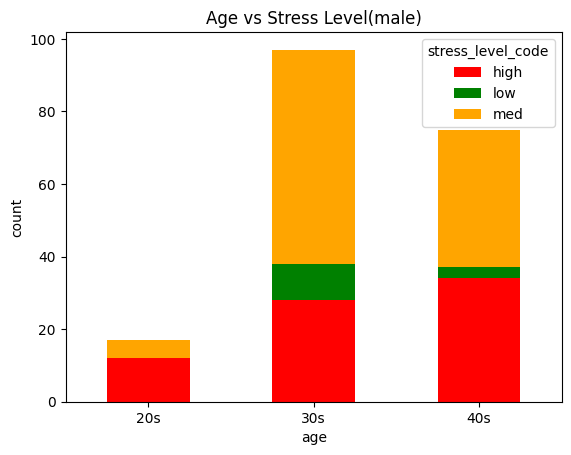

In [19]:
stress_male = df[df.gender == "Male"].groupby("age_cat")["stress_level_code"].value_counts().unstack()
m = stress_male.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("count")
plt.xlabel("age")
plt.title("Age vs Stress Level(male)")
plt.xticks(rotation=0)
plt.show(m)

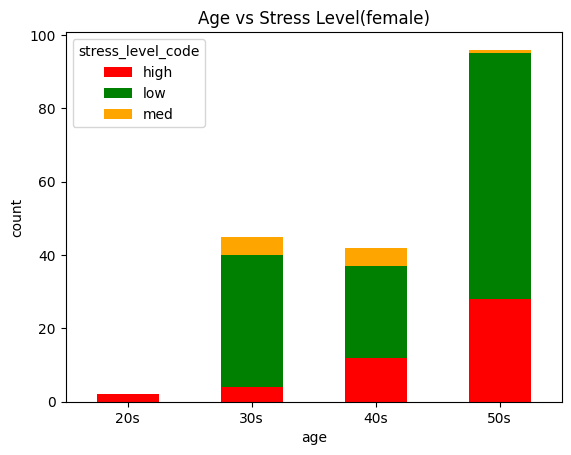

In [20]:
stress_female = df[df.gender == "Female"].groupby("age_cat")["stress_level_code"].value_counts().unstack()
f = stress_female.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("count")
plt.xlabel("age")
plt.title("Age vs Stress Level(female)")
plt.xticks(rotation=0)
plt.show(f)

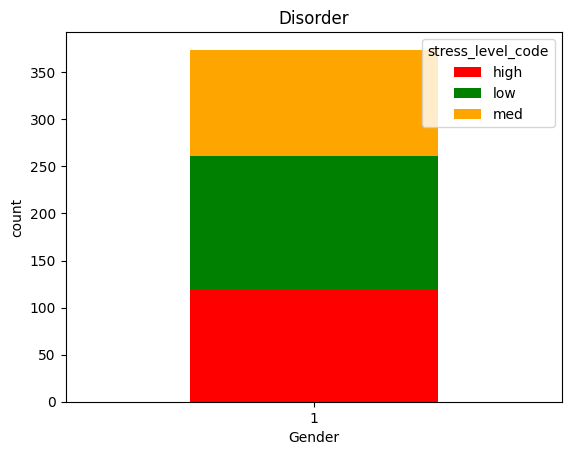

In [51]:
disorder = df.groupby("sleep_disorder")["stress_level_code"].value_counts().unstack()
f = disorder.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("count")
plt.xlabel("Gender")
plt.title("Disorder")
plt.xticks(rotation=0)
plt.show(f)

In [ ]:
disorder = df.groupby("gender")["sleep_disorder"].value_counts().unstack()
f = disorder.plot.bar(stacked =True, color=["red", "green"] )
plt.ylabel("count")
plt.xlabel("Gender")
plt.title("Disorder")
plt.xticks(rotation=0)
plt.show(f)

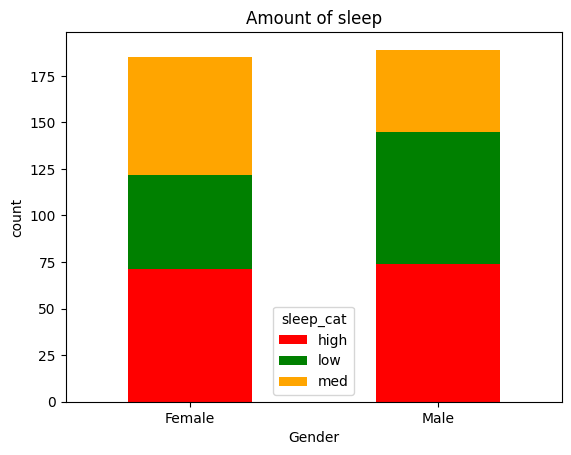

In [22]:
sleep = df.groupby("gender")["sleep_cat"].value_counts().unstack()
f = sleep.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("count")
plt.xlabel("Gender")
plt.title("Amount of sleep")
plt.xticks(rotation=0)
plt.show(f)

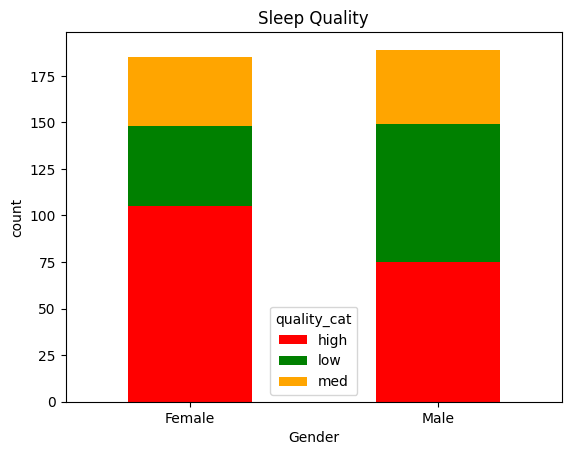

In [23]:
sleepQ = df.groupby("gender")["quality_cat"].value_counts().unstack()
f = sleepQ.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("count")
plt.xlabel("Gender")
plt.title("Sleep Quality")
plt.xticks(rotation=0)
plt.show(f)

stress_level_code  low  med
sleep_duration             
8.0                 78   67


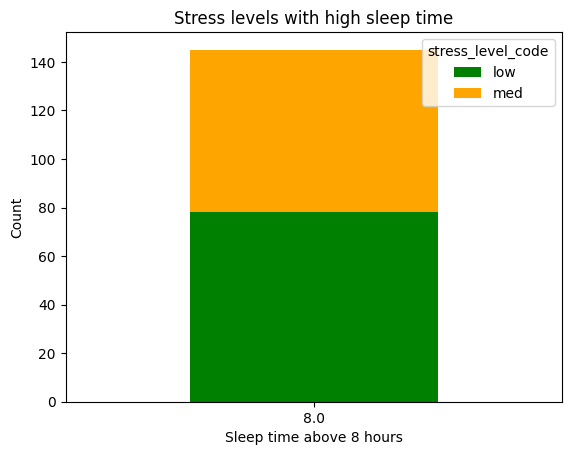

In [24]:
stress_high_sleep = df[df["sleep_cat"] == "high"].groupby("sleep_duration")["stress_level_code"].value_counts().unstack()
print(stress_high_sleep)
f = stress_high_sleep.plot.bar(stacked =True, color=["green", "orange"] )
plt.ylabel("Count")
plt.xlabel("Sleep time above 8 hours")
plt.title("Stress levels with high sleep time")
plt.xticks(rotation=0)
plt.show(f)


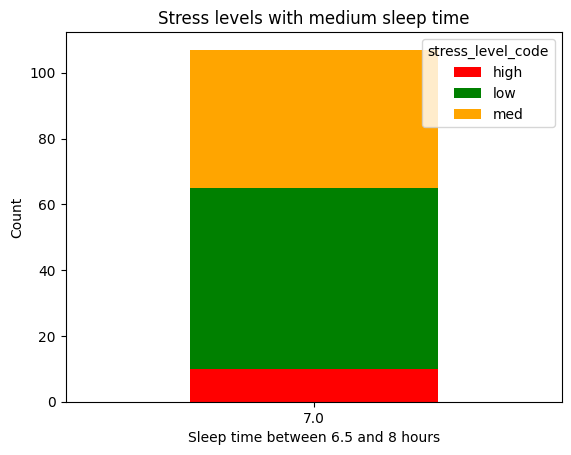

In [25]:
stress_mid_sleep = df[(df["sleep_cat"] == "med")].groupby("sleep_duration")["stress_level_code"].value_counts().unstack()
f = stress_mid_sleep.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("Count")
plt.xlabel("Sleep time between 6.5 and 8 hours")
plt.title("Stress levels with medium sleep time")
plt.xticks(rotation=0)
plt.show(f)

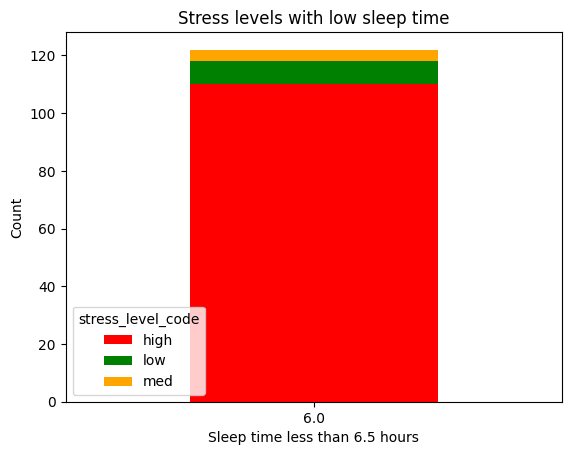

In [26]:
stress_low_sleep = df[df["sleep_cat"] == "low"].groupby("sleep_duration")["stress_level_code"].value_counts().unstack()
f = stress_low_sleep.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("Count")
plt.xlabel("Sleep time less than 6.5 hours")
plt.title("Stress levels with low sleep time")
plt.xticks(rotation=0)
plt.show(f)

stress_level_code            low   med
sleep_duration quality_cat            
8.0            high         78.0  35.0
               med           NaN  32.0


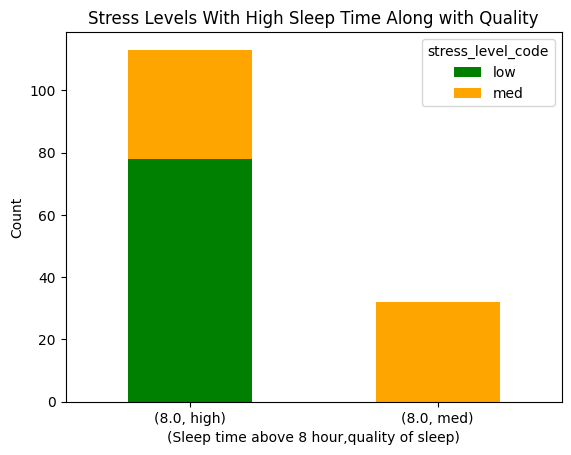

In [27]:
stress_high_sleep = df[df["sleep_cat"] == "high"].groupby(["sleep_duration","quality_cat"])["stress_level_code"].value_counts().unstack()
print(stress_high_sleep)
f = stress_high_sleep.plot.bar(stacked =True, color=["green", "orange"] )
plt.ylabel("Count")
plt.xlabel("(Sleep time above 8 hour,quality of sleep)")
plt.title("Stress Levels With High Sleep Time Along with Quality")
plt.xticks(rotation=0)
plt.show(f)

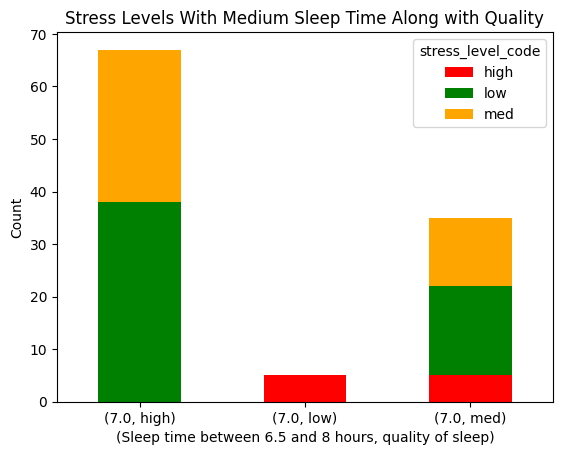

In [28]:
stress_mid_sleep = df[(df["sleep_cat"] == "med")].groupby(["sleep_duration", "quality_cat"])["stress_level_code"].value_counts().unstack()
f = stress_mid_sleep.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("Count")
plt.xlabel("(Sleep time between 6.5 and 8 hours, quality of sleep)")
plt.title("Stress Levels With Medium Sleep Time Along with Quality")
plt.xticks(rotation=0)
plt.show(f)

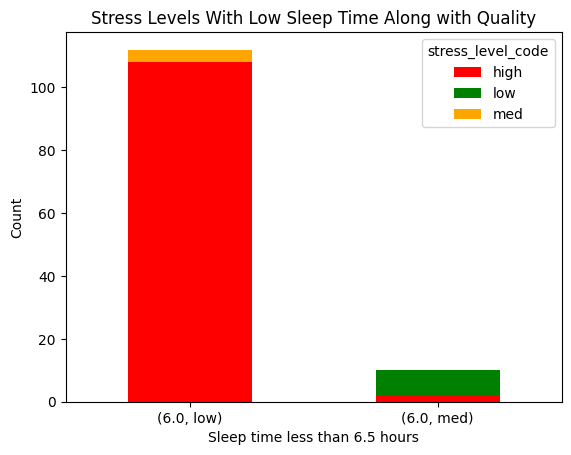

In [42]:
stress_low_sleep = df[df["sleep_cat"] == "low"].groupby(["sleep_duration", "quality_cat"])["stress_level_code"].value_counts().unstack()
f = stress_low_sleep.plot.bar(stacked =True, color=["red", "green", "orange"] )
plt.ylabel("Count")
plt.xlabel("Sleep time less than 6.5 hours")
plt.title("Stress Levels With Low Sleep Time Along with Quality")
plt.xticks(rotation=0)
plt.show(f)

## DESCRIBE

##### Using the data we collected from 374 individuals—with the minimum, maximum, and mean of their age, sleep duration, quality of sleep, and stress levels being (27.0, 59.0, 42.2), (6.0, 8.0, 7.1), (4.0, 9.0, 7.3), (3.0, 8.0, 5.4) respectively—after cleaning and analyzing this data, we answered our main question: **Does a lack of sleep affect stress level?** We also addressed the following questions: **Do age or gender influence stress levels? Are individuals with sleep disorders more likely to experience increased stress?** and **Does sleep duration and sleep quality contribute to higher stress?**#####

##### Firstly, the graphical comparisons answered the question, **Do age or even gender influence stress levels?** We concluded that age and gender do play a role in stress levels. To start, people in their 30s tended to have only high and medium stress levels. This can be explained by the fact that individuals in this age range are often focused on building their careers, establishing stability, and facing the fear of failure—factors that increase stress. Then for individuals in their 40s, we observed a significant increase in medium and low stress levels and a slight increase in high stress levels. This aligns with people becoming more grounded in their professions and lives. In the 40s, high stress increased while low and medium stress slightly decreased, likely because people at this age typically have started families or have growing children, and responsibilities such as caregiving and financial support may increase stress. Finally, in the 50s, there was a dominance of low stress levels. This age group often experiences reduced responsibilities as children move out and individuals begin retirement, relieving many stressors. Therefore, age influences stress levels—not simply because of the number itself but because of the life stage it represents. #####
##### Then for **gender**, we saw the same general trend: stress changes as individuals progress through life stages. However, another pattern appeared. Men were mostly represented in medium and high stress levels, with only a small portion experiencing low stress. Women, on the other hand, had a much larger proportion of low stress levels. This can be explained by the societal responsibilities placed on each gender—men are often expected to handle financial provision and external responsibilities, which may increase their stress. Therefore, gender affects stress levels because of the level of responsibility placed on both genders by society. Meaning we can conclude that age and gender play a role in stress levels.#####

##### Secondly, the data we analyzed answered the question, **Are individuals with sleep disorders more likely to experience increased stress?** For this question, we concluded that sleep disorders had no meaningful relationship with stress levels. When we compared individuals with sleep disorders to their stress levels, there was no significant difference in the proportion of people with low, medium, or high stress. Therefore, we concluded that sleep disorders did not play a major role in determining stress levels. #####

##### Lastly, the analysis answered the question, **Does a lack of sleep and the quality of sleep contribute to higher stress?** For this question, we concluded that sleep duration does play a role, and sleep quality plays an even more important role. When comparing sleep duration to stress levels, the analysis showed that individuals with high sleep duration experienced only low and medium stress levels, distributed fairly equally. Those with medium sleep duration showed a similar distribution, but a small number of individuals with high stress levels began to appear. Finally, individuals with low sleep duration were mostly represented in the high stress category, with very few reporting low or medium stress. Therefore, the less someone sleeps, the more likely they are to experience stress.
##### When incorporating sleep quality into the analysis, we discovered something more important: regardless of sleep duration, sleep quality had a stronger effect. For high sleep duration: (1) When sleep quality was high, low stress dominated. (2) When sleep quality was medium, individuals mostly had medium stress. **NOTE: High sleep duration had no low-quality cases in this dataset**. 
##### With medium sleep duration: (1) High sleep quality resulted in a distribution between low and medium stress. (2) Medium sleep quality produced low and medium stress levels with a tiny number experiencing high stress. (3) Low sleep quality resulted in every individual experiencing high stress. 
##### With low sleep duration: (1) Low sleep quality produced a population severely dominated by high stress. (2) Medium sleep quality, interestingly, resulted in mostly low stress levels with a very small number of high stress cases. **NOTE: Low sleep duration had no high-quality cases in this dataset**.

##### All this data allowed us to conclude that while sleep duration influences stress, sleep quality plays a much more significant role. People can still experience low stress even with less sleep if the quality of that sleep is decent. Therefore, sleep duration does play a role in stress levels, but sleep quality plays an even larger role.Therefore, given the data we imported, we were able to conclude that stress levels are not only affected by sleep duration, but also by multiple other variables such as age, gender, and sleep quality. Thus, our hypothesis is somewhat supported.













